In [1]:
import os
from pathlib import Path
import librosa

import torch
import torchaudio
import torchaudio.transforms as T

import pandas as pd
import numpy as np
from IPython.display import Audio, display
import matplotlib.pyplot as plt

import soundfile as sf
import scipy.signal as signal
from scipy.signal import butter, lfilter
from scipy.ndimage import gaussian_filter1d

ModuleNotFoundError: No module named 'librosa'

In [3]:
# Path to generated sounds
AUDIO_DIR = Path("../data/rave_sounds/synth_wind/")

In [4]:
# Get all WAV files
audio_files = sorted([f for f in AUDIO_DIR.glob("*.wav")])

# Analyse Features



In [5]:
def analyze_file(path, target_sr=48000):
    waveform, sr = torchaudio.load(path)
    if sr != target_sr:
        waveform = torchaudio.functional.resample(waveform, sr, target_sr)

    waveform = waveform.mean(dim=0, keepdim=True)  # mono
    rms = waveform.pow(2).mean().sqrt().item()
    silence_ratio = (waveform.abs() < 0.01).float().mean().item()
    
    # Spectral centroid
    spec_centroid = T.SpectralCentroid(sample_rate=target_sr)(waveform)[0].mean().item()
    
    # Zero crossing rate
    zcr = ((waveform[:, 1:] * waveform[:, :-1]) < 0).float().mean().item()

    # Crest factor
    crest = waveform.abs().max().item() / (waveform.pow(2).mean().sqrt().item() + 1e-6)

    # Dynamic range (max - mean)
    dyn_range = waveform.abs().max().item() - waveform.abs().mean().item()

    return {
        "file": str(path.name),
        "rms": rms,
        "silence_ratio": silence_ratio,
        "spectral_centroid": spec_centroid,
        "zcr": zcr,
        "crest_factor": crest,
        "dynamic_range": dyn_range
    }

# Analyze all files
features = [analyze_file(f) for f in audio_files]
df = pd.DataFrame(features)
df.head()

/Users/shrutirao/Documents/projects/study-3/biophilic-sound-engine/venv/lib/python3.13/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


,file,rms,silence_ratio,spectral_centroid,zcr,crest_factor,dynamic_range
0,office_seg001.wav,0.051787,0.806117,3586.910156,0.015127,19.309551,0.988916
1,office_seg002.wav,0.008426,0.906184,3899.638916,0.005925,11.422168,0.093363
2,office_seg003.wav,0.020760,0.900593,3907.959473,0.004793,29.896475,0.616149
3,office_seg004.wav,0.009286,0.885029,3619.823975,0.007794,24.221530,0.221448
4,office_seg005.wav,0.022954,0.844836,3595.057129,0.003385,29.025735,0.660006


In [6]:
df.zcr.describe()

count    324.000000
mean       0.007921
std        0.007965
min        0.001012
25%        0.002580
50%        0.004565
75%        0.009901
max        0.050095
Name: zcr, dtype: float64

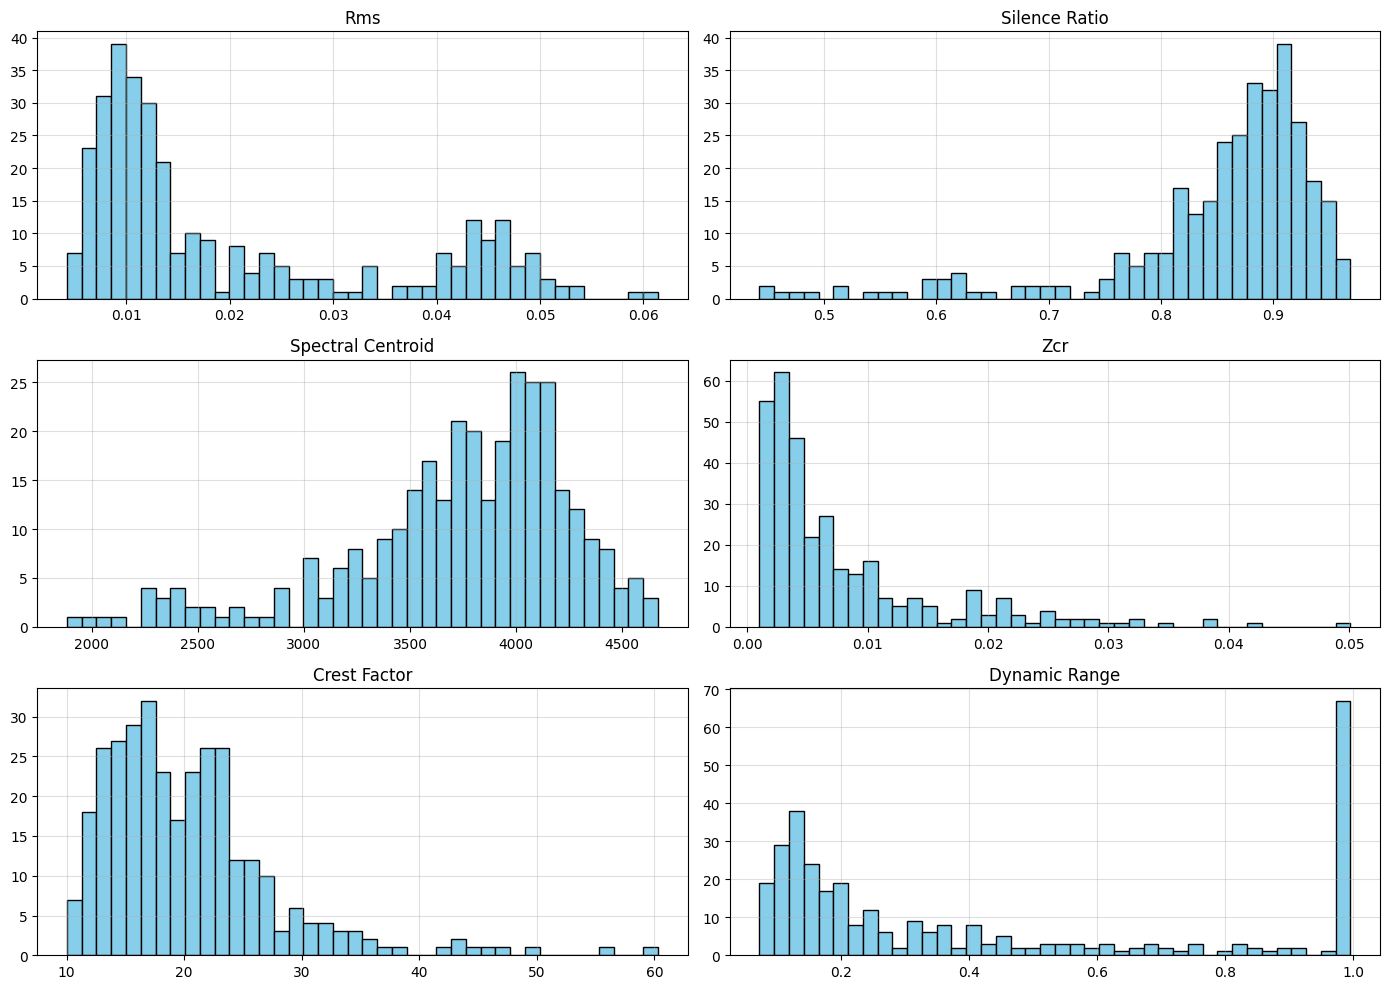

In [7]:
fig, axs = plt.subplots(3, 2, figsize=(14, 10))
cols = ["rms", "silence_ratio", "spectral_centroid", "zcr", "crest_factor", "dynamic_range"]

for ax, col in zip(axs.flat, cols):
    ax.hist(df[col], bins=40, color="skyblue", edgecolor="black")
    ax.set_title(col.replace("_", " ").title())
    ax.grid(alpha=0.4)

plt.tight_layout()
plt.show()

## Spectral Centroid

In [8]:
# Function to compute spectral centroid
def compute_centroid(file_path, sr=48000):
    y, _ = librosa.load(file_path, sr=sr)
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    return centroid.mean()

# Analyze all WAV files
file_stats = []
for f in AUDIO_DIR.glob("*.wav"):
    try:
        centroid = compute_centroid(f)
        file_stats.append({"file": f.name, "spectral_centroid": centroid})
    except Exception as e:
        print(f"⚠️ Error processing {f.name}: {e}")

# Create DataFrame
df = pd.DataFrame(file_stats)

# Sort and get top/bottom 10
lowest_10 = df.nsmallest(10, "spectral_centroid")
highest_10 = df.nlargest(10, "spectral_centroid")

# Display
print("🔻 10 Files with LOWEST Spectral Centroid:")
display(lowest_10)

print("\n🔺 10 Files with HIGHEST Spectral Centroid:")
display(highest_10)


🔻 10 Files with LOWEST Spectral Centroid:


,file,spectral_centroid
290,office_seg057.wav,2125.740783
14,office_seg058.wav,2194.713397
47,office_seg063.wav,2300.440336
95,office_seg007.wav,2362.579863
190,office_seg141.wav,2449.800104
15,office_seg064.wav,2528.353119
291,office_seg043.wav,2602.315803
76,office_seg061.wav,2603.163795
305,office_seg055.wav,2626.216853
160,office_seg026.wav,2665.768431



🔺 10 Files with HIGHEST Spectral Centroid:


,file,spectral_centroid
142,office_seg228.wav,6029.664375
41,office_seg311.wav,5957.769343
140,office_seg200.wav,5942.201025
298,office_seg323.wav,5906.790630
174,office_seg226.wav,5822.585213
124,office_seg203.wav,5809.204133
84,office_seg199.wav,5804.334666
195,office_seg237.wav,5802.462517
43,office_seg301.wav,5797.820892
145,office_seg176.wav,5760.759972


In [ ]:
sr = 48000

# Low-pass filter design
def butter_lowpass(cutoff, sr, order=6):
    nyq = 0.5 * sr
    normal_cutoff = cutoff / nyq
    return butter(order, normal_cutoff, btype='low', analog=False)

def apply_lowpass_filter(y, sr, cutoff=8000):
    b, a = butter_lowpass(cutoff, sr)
    return lfilter(b, a, y)

# Apply to top 10 highest spectral centroid files
cutoff_freq = 4500  # in Hz

for i, row in highest_10.iterrows():
    file_path = AUDIO_DIR / row["file"]
    print(f"\n🎧 File: {row['file']} — Spectral Centroid: {row['spectral_centroid']:.2f} Hz")
    
    # Load
    y, _ = librosa.load(file_path, sr=sr, mono=True)

    # Apply low-pass filter
    y_filtered = apply_lowpass_filter(y, sr, cutoff=cutoff_freq)

    # Listen
    print("Original:")
    display(Audio(y, rate=sr))

    print(f"Filtered (Low-pass @ {cutoff_freq} Hz):")
    display(Audio(y_filtered, rate=sr))


ZCR

Crest Factors

Dynamic Rangem

i didnt find the too low ones overly muffled so lets address too high spectral centroid,. before i aplly these changes lets majke a list of all the changes and then pply and transform all the sounds altogether at the end so make a notye of the spectral centroid order: Apply a low-pass filter (~4kHz cutoff) to reduce sharpness



## ZCR

In [ ]:
 # Compute ZCR for each file
def compute_zcr(file_path, sr=48000):
    y, _ = librosa.load(file_path, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(y)
    return zcr.mean()

# Collect ZCR stats
zcr_stats = []
for f in AUDIO_DIR.glob("*.wav"):
    try:
        zcr = compute_zcr(f)
        zcr_stats.append({"file": f.name, "zcr": zcr})
    except Exception as e:
        print(f"⚠️ Error processing {f.name}: {e}")

zcr_df = pd.DataFrame(zcr_stats)

# Sort by highest ZCR
zcr_top = zcr_df.sort_values("zcr", ascending=False).head(50)
print("🔺 10 files with highest ZCR:")
display(zcr_top)

# Listen to them
for fname in zcr_top["file"]:
    file_path = AUDIO_DIR / fname
    print(f"\n🔊 Playing: {fname}")
    display(Audio(file_path))


In [ ]:
def lowpass_filter(audio, sr, cutoff_hz=3000):
    nyquist = 0.5 * sr
    norm_cutoff = cutoff_hz / nyquist
    b, a = signal.butter(4, norm_cutoff, btype='low', analog=False)
    return signal.filtfilt(b, a, audio)

def fade_in_out(audio, sr, fade_duration=0.5):
    fade_samples = int(fade_duration * sr)
    fade_in = np.linspace(0.0, 1.0, fade_samples)
    fade_out = np.linspace(1.0, 0.0, fade_samples)
    audio[:fade_samples] *= fade_in
    audio[-fade_samples:] *= fade_out
    return audio

def process_high_zcr_file(file_path, output_path):
    y, sr = librosa.load(file_path, sr=48000)
    y = lowpass_filter(y, sr, cutoff_hz=3000)
    y = fade_in_out(y, sr, fade_duration=10.9)
    sf.write(output_path, y, sr)

# Example: apply to a top-ZCR file
f = AUDIO_DIR / zcr_top.iloc[0]["file"]
out = AUDIO_DIR / "postprocessed" / f.name
os.makedirs(out.parent, exist_ok=True)
process_high_zcr_file(f, out)

# Listen to result
print(f"\n🔉 Processed version of {f.name}:")
display(Audio(out))

In [ ]:
from scipy.ndimage import gaussian_filter1d
import soundfile as sf

# Get the file with the highest ZCR
top_zcr_row = df.loc[df['zcr'].idxmax()]
file_path = AUDIO_DIR / top_zcr_row["file"]
output_path = AUDIO_DIR / f"smoothed_{file_path.name}"

# Define smoothing + fade-in/out function
def spectral_smooth_with_fade(file_path, output_path, sr=48000, fade_duration=10.5, smoothing_sigma=3):
    y, _ = librosa.load(file_path, sr=sr)

    # Fade-in and fade-out
    fade_samples = int(fade_duration * sr)
    fade_in = np.linspace(0, 1, fade_samples)
    fade_out = np.linspace(1, 0, fade_samples)
    y[:fade_samples] *= fade_in
    y[-fade_samples:] *= fade_out

    # STFT and smoothing
    D = librosa.stft(y, n_fft=1024, hop_length=512)
    magnitude, phase = np.abs(D), np.angle(D)
    smoothed_mag = gaussian_filter1d(magnitude, sigma=smoothing_sigma, axis=0)

    # Reconstruct
    D_smooth = smoothed_mag * np.exp(1j * phase)
    y_smooth = librosa.istft(D_smooth, hop_length=512)
    y_smooth /= np.max(np.abs(y_smooth) + 1e-6)  # Normalize

    # Save
    sf.write(output_path, y_smooth, sr)

# Run it
spectral_smooth_with_fade(file_path, output_path)

# Playback comparison
print("🔊 Original:")
display(Audio(file_path))
print("✨ Smoothed:")
display(Audio(output_path))


# Crest factor

In [ ]:
df.crest_factor.describe()

In [ ]:
# --- Fix librosa compatibility with NumPy ---
import numpy as np
np.complex = complex  # Patch deprecated usage in librosa

# --- Imports ---
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from pathlib import Path
import pandas as pd

# --- Directory ---
AUDIO_DIR = Path("../data/rave_sounds/synth_wind/")
SR = 48000

# --- Crest Factor Calculation ---
def compute_crest_factor(file_path):
    y, _ = librosa.load(file_path, sr=SR)
    peak = np.max(np.abs(y))
    rms = np.sqrt(np.mean(y**2))
    if rms == 0:
        return 0
    return peak / rms

# --- Analyze all files ---
file_stats = []
for file in AUDIO_DIR.glob("*.wav"):
    try:
        crest = compute_crest_factor(file)
        file_stats.append({"file": file, "crest": crest})
    except Exception as e:
        print(f"⚠️ Error processing {file.name}: {e}")

df = pd.DataFrame(file_stats).sort_values(by="crest", ascending=False)

# --- Top Crest Factor Files > 30 ---
print("🔺 Crest Factor > 30:")
df_high30 = df[df["crest"] > 30].head(10)
for row in df_high30.itertuples():
    print(f"🎧 {row.file.name} | Crest: {row.crest:.2f}")
    display(Audio(filename=row.file, rate=SR))

# --- Crest Factor > 20 but ≤ 30 ---
print("\n🔸 Crest Factor > 20 and ≤ 30:")
df_high20 = df[(df["crest"] > 20) & (df["crest"] <= 30)].head(10)
for row in df_high20.itertuples():
    print(f"🎧 {row.file.name} | Crest: {row.crest:.2f}")
    display(Audio(filename=row.file, rate=SR))


In [ ]:
SR = 48000
FADE_DURATION = 10.9  # seconds
CREST_THRESHOLD = 30 

# Helper functions
def compute_crest_factor(y):
    peak = np.max(np.abs(y))
    rms = np.sqrt(np.mean(y**2))
    return peak / rms if rms > 0 else 0

def normalize_peak(y, target_peak=0.95):
    peak = np.max(np.abs(y))
    return y * (target_peak / peak) if peak > 0 else y

def spectral_smoothing(y, sr):
    stft = librosa.stft(y)
    mag, phase = np.abs(stft), np.angle(stft)
    smoothed_mag = scipy.signal.medfilt2d(mag, kernel_size=(5, 3))
    smoothed = smoothed_mag * np.exp(1j * phase)
    return librosa.istft(smoothed)

def fade_in_out(y, sr, duration=FADE_DURATION):
    fade_samples = int(duration * sr)
    fade = np.linspace(0, 1, fade_samples)
    y[:fade_samples] *= fade
    y[-fade_samples:] *= fade[::-1]
    return y

def gentle_post_process(y, sr):
    y = fade_in_out(y, sr)
    y = normalize_peak(y)
    y = spectral_smoothing(y, sr)
    return y

# Scan and compute crest factor
file_stats = []
for wav in AUDIO_DIR.glob("*.wav"):
    try:
        y, _ = librosa.load(wav, sr=SR)
        crest = compute_crest_factor(y)
        file_stats.append({"file": wav.name, "crest_factor": crest})
    except Exception as e:
        print(f"⚠️ Error with {wav.name}: {e}")

df = pd.DataFrame(file_stats)
df = df[df["crest_factor"] > CREST_THRESHOLD].sort_values("crest_factor", ascending=False)

# Preview top 5
for idx, row in df.head(5).iterrows():
    path = AUDIO_DIR / row["file"]
    y, _ = librosa.load(path, sr=SR)
    processed = gentle_post_process(y, SR)

    print(f"\n🎧 {row['file']} — Crest Factor: {row['crest_factor']:.2f}")
    print("🔊 Original:")
    display(Audio(data=y, rate=SR))
    print("🎛 Processed:")
    display(Audio(data=processed, rate=SR))

so i low pass filter for spectral centroid.
some clips start with a sudden loud sound, remove them (cliptyhat part
for zcr, fade in and out with 10.9 as fade + flow[pass for 3000hz ---doi this for high zcr files only > 0.2zcr

## Dynamic Range

In [ ]:
df.dynamic_range.describe()

In [ ]:
from IPython.display import Audio, display

# Ensure this column exists
assert "dynamic_range" in df.columns

# Sort by dynamic range
lowest_dr = df.nsmallest(2, "dynamic_range")
highest_dr = df.nlargest(2, "dynamic_range")

print("🔻 LOW Dynamic Range (likely dull):")
for _, row in lowest_dr.iterrows():
    print(f"🔊 {row['file']} | DR: {row['dynamic_range']:.4f}")
    display(Audio(AUDIO_DIR / row['file']))

print("\n🔺 HIGH Dynamic Range (possibly jumpy):")
for _, row in highest_dr.iterrows():
    print(f"🔊 {row['file']} | DR: {row['dynamic_range']:.4f}")
    display(Audio(AUDIO_DIR / row['file']))


In [ ]:
def detect_leading_spikes(audio_dir, sr=SR, check_duration=0.5, tail_duration=1.0, spike_ratio=3.0):
    spike_files = []

    for file_path in sorted(audio_dir.glob("*.wav")):
        try:
            y, _ = librosa.load(file_path, sr=sr)

            n_check = int(check_duration * sr)
            n_tail = int(tail_duration * sr)

            # Leading segment and following tail
            leading = y[:n_check]
            trailing = y[n_check:n_check + n_tail]

            if len(trailing) < n_tail:
                continue  # skip short files

            rms_leading = np.sqrt(np.mean(leading ** 2))
            rms_trailing = np.sqrt(np.mean(trailing ** 2))

            if rms_leading > spike_ratio * rms_trailing:
                spike_files.append({
                    "file": file_path.name,
                    "rms_leading": rms_leading,
                    "rms_trailing": rms_trailing,
                    "ratio": rms_leading / rms_trailing
                })

        except Exception as e:
            print(f"⚠️ Error processing {file_path.name}: {e}")

    return pd.DataFrame(spike_files)


In [ ]:
spike_df = detect_leading_spikes(AUDIO_DIR)
print(f"🚨 Detected {len(spike_df)} files with suspicious loud beginnings:")
display(spike_df.sort_values("ratio", ascending=False))


In [ ]:
import librosa
from pathlib import Path
import numpy as np

AUDIO_DIR = Path("../data/rave_sounds/synth_wind/")
sr = 48000
burst_threshold = 0.9  # Adjust based on empirical inspection
window_duration = 0.5  # Seconds to scan at start
window_samples = int(sr * window_duration)

suspicious_files = []

for file in AUDIO_DIR.glob("*.wav"):
    y, _ = librosa.load(file, sr=sr)
    if len(y) < window_samples:
        continue
    start_segment = y[:window_samples]
    
    peak = np.max(np.abs(start_segment))
    
    if peak > burst_threshold:
        suspicious_files.append((file.name, peak))

# Print results
print(f"⚠️ Detected {len(suspicious_files)} files with loud start artifacts:\n")
for fname, peak in suspicious_files:
    print(f"{fname} – peak = {peak:.3f}")
